#Transfer Learning with Med MNIST.

In this assignment you will use transfer learning to train a model of your choice on a sub-dataset from the [MedMNIST datasets](https://medmnist.com/). ![](https://github.com/tonyscan6003/etivities/blob/main/medmnist.JPG?raw=true)

* The [MedMNIST package](https://github.com/MedMNIST/MedMNIST/blob/main/examples/getting_started.ipynb) allows the data to be imported directly as a pytorch dataset.

* You may select any of the datasets using Multi-class/binary classification. The goal is to acheve accuracy levels comparable to the benchmark results shown on the medmnist site. Dataloading for pytorch is setup in the notebook, you wil need to modify the code slightly depending on your dataset of choice.

* Some datasets use black and white images, so you will need to [at least concatenate](https://towardsdatascience.com/transfer-learning-on-greyscale-images-how-to-fine-tune-pretrained-models-on-black-and-white-9a5150755c7a) the input image channels (to 3 channels) for compatibility with the models pre-trained on imageNet.

* Some of the MedMNIST datasets don't contain too much data so Data augmentation may be essentila essential to avoid overfitting. In pytorch data augmentation is performed using the [transforms.v2](https://pytorch.org/vision/main/transforms.html) modules.

* In this notebook: You will need to import a model, and perform training. Tranfer Learning for computer vision is detailed [here](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

* [Tensorboard can be imported](https://pytorch.org/tutorials/beginner/introyt/tensorboardyt_tutorial.html) to display results.

* Please only include one example of transfer learning in the submitted notebook. Making sure training curves/results are clearly visible. If you have trained additional transfer learning models (i.e. that were less successful) please add this as a table or report at the end of the notebook and/or in your final forum post.




# 1. Install & Import Packages

In [3]:
!pip install medmnist
!pip install torchinfo

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models
from torchvision.models import resnet18, resnet50, ResNet18_Weights, ResNet50_Weights
from torchvision.transforms import ToTensor, v2, Grayscale
import matplotlib.pyplot as plt
import numpy as np

## 2. Setup & Import Dataset
The [MedMNSIT](https://medmnist.com/) package (imported above) makes available several medical datasets available to access.

You can change the `data_flag` variable (dataset names are all lower case letters) to the dataset of your choice (Take care to note the parameters e.g. number of input channels below that will affect your model)



In [6]:
import medmnist
from medmnist import INFO, Evaluator
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.tensorboard import SummaryWriter

data_flag = 'bloodmnist' #smaller dataset as suggested (Conor)
download = True

BATCH_SIZE = 32 #reduced to save time
IMAGE_SIZE = 64 #reduced to save tiem

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

print('Type of Machine Learning Task = ',task)
print('Number of Input Data Channels = ',n_channels)
print('Number of Classes = ',n_classes)
print('The batch size for this dataset will be = ',BATCH_SIZE)

DataClass = getattr(medmnist, info['python_class'])

Type of Machine Learning Task =  multi-class
Number of Input Data Channels =  3
Number of Classes =  8
The batch size for this dataset will be =  32


Transforms:
You can update the functions below with appropriate transforms for your particular use case.

* As well as being suitable for data augmention for image classification, the transforms.v2 package of torchvision extends transforms for object detection and segmentation tasks. An illustration of the transforms is shown [here](https://pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html#sphx-glr-auto-examples-transforms-plot-transforms-illustrations-py).
* Normalisation based on ImageNet parameters is included already. This should be used with all models pre-trained on ImageNet  





In [8]:
#Defining transforms here (with channel expansion)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

#Training transforms with augmentation
train_transforms = v2.Compose([
v2.ToDtype(torch.float32, scale=True),
Grayscale(num_output_channels=3) if n_channels == 1 else v2.Identity(),
ToTensor(),
v2.RandomHorizontalFlip(), #Simple augmentation to help model generalise
v2.RandomRotation(15), #Rotation to help prevent overfitting on orientation(15)
v2.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)), # Random crop to improve robustness
v2.Normalize(imagenet_mean, imagenet_std) #Required for ImageNet pretrained models
])

test_transforms = v2.Compose([
v2.ToDtype(torch.float32, scale=True),
Grayscale(num_output_channels=3) if n_channels == 1 else v2.Identity(),
ToTensor(),
v2.Resize((IMAGE_SIZE, IMAGE_SIZE)),
v2.Normalize(imagenet_mean, imagenet_std)
])

Setup your Medmnist dataset.
* The convolution part of pre-trained networks (such as resnet) are compatable with any size input image. However they were trained on 224 x 224 size images, with early layers finding small scale features and deeper layers finding large scale features.
* For this transfer learning application to medical data, the gap between the original ImageNet domain and the medical images is wide. Therefore the size/scale of the input images is less important, however in general we would expect better performance with the larger input images (as they contain more features at different scales).
* You can add the `size=224` parameter to the dataset object calls, to load full size images. Only do this once you are confident in your training methodology (or if the dataset is small), as training with full size images will take longer.


In [10]:
#Load original and augmented datasets separately, then combine
train_dataset_aug = DataClass(split='train', transform=train_transforms, download=download, size=IMAGE_SIZE, mmap_mode='r')
train_dataset_orig = DataClass(split='train', transform=test_transforms, download=download, size=IMAGE_SIZE, mmap_mode='r')
val_dataset = DataClass(split='val', transform=test_transforms, download=download, size=IMAGE_SIZE, mmap_mode='r')
test_dataset = DataClass(split='test', transform=test_transforms, download=download, size=IMAGE_SIZE, mmap_mode='r')


100%|███████████████████████████████████████████████████████████████████████████████| 156M/156M [00:47<00:00, 3.31MB/s]


In [11]:
#Combine original + augmented training datasets
train_dataset_both = torch.utils.data.ConcatDataset([train_dataset_aug, train_dataset_orig])


The `Dataset` is passed as an argument to `DataLoader`. This wraps an
iterable over the dataset, and supports automatic batching, sampling,
shuffling and multiprocess data loading.

In [13]:
# Create data loaders.
train_dataloader = DataLoader(dataset=train_dataset_both, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([32, 3, 64, 64])
Shape of y: torch.Size([32, 1]) torch.int32


Plot some example augmented images

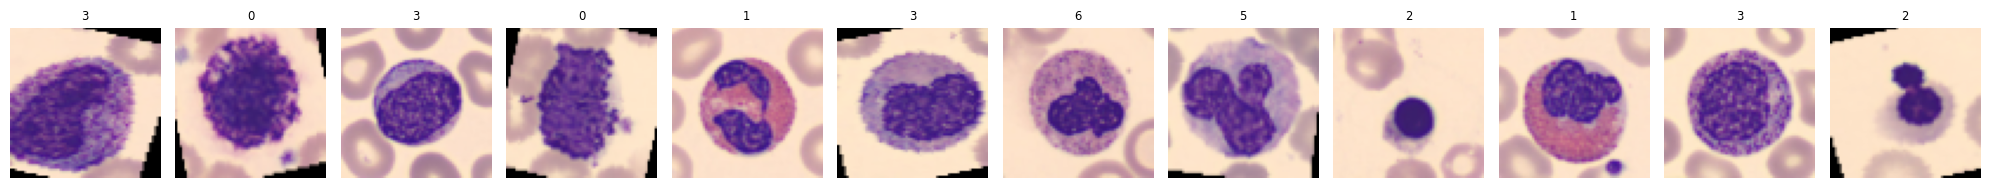

In [15]:
# Output next batch from dataloader
dataiter = iter(train_dataloader)
image_batch, labels_batch = next(dataiter)

#Set ImageNet mean and std for un-normalising
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

#Use matplotlib to plot a sample of images
n_plots = 12 # number of plots
f, axarr = plt.subplots(1,n_plots,figsize=(20,10))

for i in range(n_plots):
    image = image_batch[i]
    #Convert to HWC format
    disp_image = torch.permute(image, (1, 2, 0)).numpy()
    #Un-normalise
    disp_image = std * disp_image + mean
    disp_image = np.clip(disp_image, 0, 1)
    #Plot
    axarr[i].imshow(disp_image)
    axarr[i].axis("off")
    axarr[i].set_title(labels_batch[i].item(), fontsize='small')

plt.tight_layout()
plt.show()

# 3. Define Transfer Learning model
Pytorch has an inbuilt [models package](https://pytorch.org/vision/stable/models.html) that allows loading of popular models with pre-trained weights.

* We want to add an additional classifier stage (to the output of the network). How to setup the [model is detailed here](https://discuss.pytorch.org/t/load-only-a-part-of-the-network-with-pretrained-weights/88397/2).
* This additional classifier may just be a single layer or a cascade of fully connected layers with dropout.
* Note that the number of parameters in the convolutional part of the model will be same no what the input size is set to. However the output feature map size will vary with input image size (small for small image, large for large image). This means the number of parameters in the additional classifier will change depending on input image size.


In [17]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


In [18]:
#Loading a pretrained ResNet18 model
from torchvision.models import resnet50, ResNet50_Weights

#Load ResNet50 with pretrained ImageNet weights
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

#Freezing all feature extractor layers
for param in model.parameters():
    param.requires_grad = False #prevent updates to pretrained weights

#Replacing the final fully connected (fc) layer with a custom classifier for my dataset
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256), #first dense layer
    nn.ReLU(),
    nn.Dropout(0.4), #prevent overfitting
    nn.Linear(256, n_classes) #final output layer with correct number of classes
)

#Moving model to device
model = model.to(device)

# 4. Optimisation & Training Loop

Define a training loop that prints the loss from the training and validation set at least every epoch.
* You may choose to make the validation loss calculations more frequent so you can ensure training is progressing satisfactorily (especially with larger datasets).

* You can use tensorboard to visualise the [loss curves](https://pytorch.org/docs/stable/tensorboard.html))

* For multi-class classification classification problem we will use the  [CrossEntropy loss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html). In this pytorch function, the input is the un-normalised logit value.

* You may  have to use [torch.squeeze](https://pytorch.org/docs/stable/generated/torch.squeeze.html) to reduce the dimensionality of the label tensor before passing it to the loss function (this due to how the dataset is configured and the loss will only accept 0D or 1D inputs)

In [20]:
#Defining loss function for multi-class classification
criterion = nn.CrossEntropyLoss() #expects logits (no softmax) and class indices

#Optimiser: only update parameters that require gradients
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)

#Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

Initialise Tensorboard (use of tensorboard in colab notebooks is [detailed here](https://colab.research.google.com/github/tensorflow/tensorboard/blob/master/docs/tensorboard_in_notebooks.ipynb)). A [Pytorch tutorial](https://pytorch.org/tutorials/beginner/introyt/tensorboardyt_tutorial.html) shows how to setup the training and validation loop with pytorch.


In [22]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs/bloodmnist_resnet50')

In [49]:
#Training and validation functions
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for i, (inputs, labels) in enumerate(dataloader):
        inputs = inputs.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

#validation loop
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.squeeze().long().to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [51]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Using device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))


GPU available: False
Using device: cpu


In [53]:
#Run training
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_dataloader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_dataloader, criterion, device)

    #Step the scheduler
    scheduler.step(val_loss)

    #Print progress
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    #Log to TensorBoard
    writer.add_scalars("Loss", {"Train": train_loss, "Val": val_loss}, epoch)
    writer.add_scalars("Accuracy", {"Train": train_acc, "Val": val_acc}, epoch)

writer.close()
print("Training complete.")

Epoch 1/10
  Train Loss: 0.3744 | Train Acc: 0.8693
  Val   Loss: 0.3061 | Val   Acc: 0.8989
Epoch 2/10
  Train Loss: 0.3736 | Train Acc: 0.8686
  Val   Loss: 0.3055 | Val   Acc: 0.8931
Epoch 3/10
  Train Loss: 0.3612 | Train Acc: 0.8739
  Val   Loss: 0.3036 | Val   Acc: 0.8960
Epoch 4/10
  Train Loss: 0.3603 | Train Acc: 0.8761
  Val   Loss: 0.2746 | Val   Acc: 0.9013
Epoch 5/10
  Train Loss: 0.3581 | Train Acc: 0.8742
  Val   Loss: 0.2692 | Val   Acc: 0.9065
Epoch 6/10
  Train Loss: 0.3626 | Train Acc: 0.8754
  Val   Loss: 0.2891 | Val   Acc: 0.8995
Epoch 7/10
  Train Loss: 0.3436 | Train Acc: 0.8803
  Val   Loss: 0.3078 | Val   Acc: 0.8937
Epoch 8/10
  Train Loss: 0.3309 | Train Acc: 0.8826
  Val   Loss: 0.2965 | Val   Acc: 0.8960
Epoch 9/10
  Train Loss: 0.3334 | Train Acc: 0.8833
  Val   Loss: 0.2960 | Val   Acc: 0.9007
Epoch 10/10
  Train Loss: 0.3120 | Train Acc: 0.8915
  Val   Loss: 0.2895 | Val   Acc: 0.9048
Training complete.


# 5. Evaluate Model
You will need to setup an evaluation loop for the model to assess it's performance on the test dataset.

You may also obtain a classification report after final evaluation of the test dataset with the model using the code below. A confusion matrix can also be obtained and we will plot a few example images.



In [66]:
#https://scikit-learn.org/0.16/auto_examples/model_selection/plot_confusion_matrix.html
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

#Collecting prediction and true labels from test set
y_true = []
y_pred = []

model.eval() #setting model to evaluation mode
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.squeeze().to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

#Classification report
print("\nClassification Report:")
classes = list(info['label'].values()) #'defining class names
print(classification_report(y_true, y_pred, target_names=list(info['label'].values())))


Classification Report:
                                                                     precision    recall  f1-score   support

                                                           basophil       0.88      0.88      0.88       244
                                                         eosinophil       0.99      0.97      0.98       624
                                                       erythroblast       0.89      0.87      0.88       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)       0.81      0.85      0.83       579
                                                         lymphocyte       0.88      0.90      0.89       243
                                                           monocyte       0.88      0.77      0.82       284
                                                         neutrophil       0.93      0.93      0.93       666
                                                           platelet       0.96      0.99      0.97     

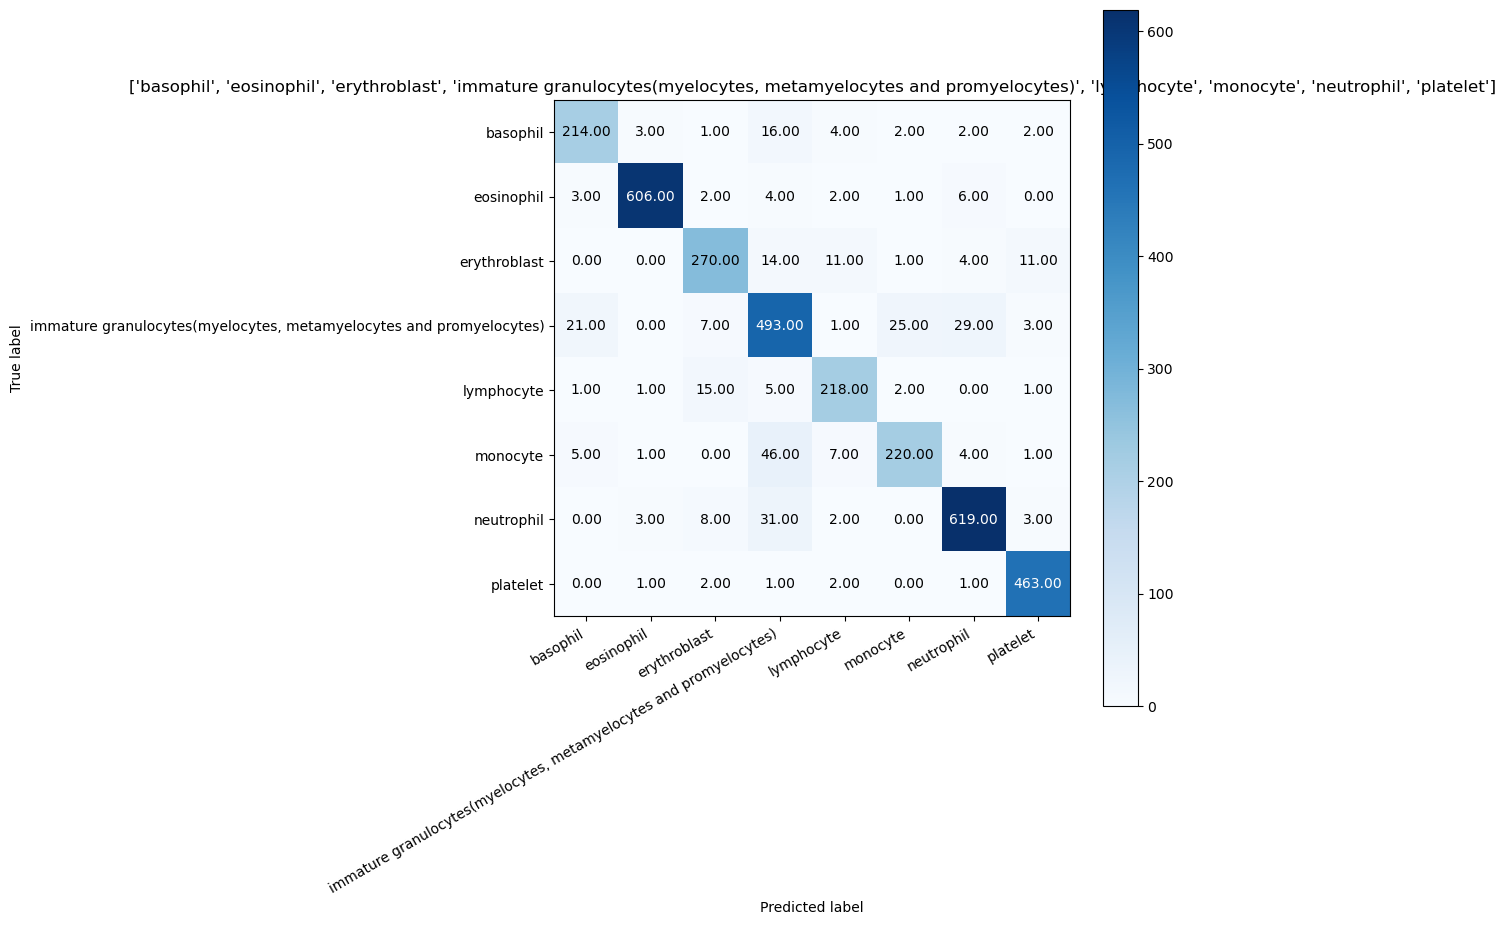

In [75]:
cm = confusion_matrix(y_true, y_pred)

def plot_confusion_matrix(cm, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(12, 10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=30, ha='right', fontsize=10)
    plt.yticks(tick_marks, classes)

    fmt = '.2f'
    thresh = cm.max() / 1.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha='center', va='center',
                     color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

plot_confusion_matrix(cm, classes)

 # Comments about your Approach

At the beginning of this task, I selected BloodMNIST after initially considering PathMNIST. I made this change due to challenges I faced with PathMNIST, particularly the larger dataset size and longer training times, which became impractical with limited computational resources and time constraints. BloodMNIST offered a more manageable dataset size, faster iteration cycles, and allowed me to focus more on improving training strategy rather than just waiting for results.

I implemented transfer learning using a ResNet50 model pretrained on ImageNet. I froze the backbone and added a custom classifier with dropout for regularisation. At first, training performance improved steadily, but validation accuracy remained inconsistent. After adding data augmentation (horizontal flips, rotations, and random resized cropping), generalisation improved significantly. This confirmed that augmentation was critical to bridging the domain gap between ImageNet and BloodMNIST, as others in the forum had also found.

Due to limited compute, I reduced the image size to 64×64 and batch size to 32, which helped speed up training while maintaining reasonable accuracy. I trained for only 5 epochs initially and achieved a validation accuracy of around 89.5%, which was already close to the benchmark. Encouraged by this, I extended training to 10 epochs, and test set results showed further improvement with 90% accuracy and balanced precision/recall across all 8 classes.

In hindsight, the biggest challenges were:

Understanding why validation performance fluctuated early on.

Managing training times without access to GPU acceleration.

Deciding when and how to apply augmentation and learning rate strategies.

If I had more time, I would experiment with:

Fine-tuning some of the later layers of ResNet50 (instead of freezing all of them).

Exploring alternative models like MobileNetV2 for faster training.

Running more extensive hyperparameter tuning, particularly for learning rates and dropout.

Overall, this project helped me understand how to practically apply transfer learning, and how each component (augmentation, learning rates, schedulers) contributes to improving model performance. I also learned the importance of adapting to constraints, such as time and compute, while still aiming for strong results.